In [266]:
import kagglehub
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import sklearn
from sklearn.model_selection import StratifiedShuffleSplit
from pandas.plotting import scatter_matrix
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import rbf_kernel
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.compose import ColumnTransformer
from sklearn.compose import make_column_selector, make_column_transformer
from sklearn.feature_selection import SelectFromModel
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR # remember it doesnt scale well to big data sets
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform, reciprocal
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import FunctionTransformer
from sklearn.metrics import root_mean_squared_error
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
import os
from pandas.plotting import scatter_matrix

In [267]:
# Download latest version
path = kagglehub.dataset_download("nehalbirla/vehicle-dataset-from-cardekho")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\jubel\.cache\kagglehub\datasets\nehalbirla\vehicle-dataset-from-cardekho\versions\4


In [268]:
csv_path = os.path.join(path, "car data.csv")  #path is the folder, car data.csv is the file. They need to be joined to create a complete search path 
cars_full = pd.read_csv(csv_path)

## Frame the problem - look at the big picture

we need predict how much used cars can be sold for, in order to know for example if it is worth it to fix it up. How much would we make of cars, based on some information about it.

Without a prediction model, the experienced car salesmen and machanics would be the experts to consult for this problem. The model could maybe save time for them. Since the model will be trained on lots of data it will hopefully be able to predict even better than them. 

since we have one data set that we will no be updating, it will be an offline model. It is also supervised, since we have the labels, i think. And since we want to predict values - that makes it a regerssion task, ha! Multiple regression, since we have several features.

Perfomance measure - RMSE is the typical performance measure for regression problems. Gives an idea of how much error the system typically makes in its predictions, with a higher weight given to large errors. 

In [269]:
cars_full.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [270]:
cars_full.info()

<class 'pandas.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    str    
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Kms_Driven     301 non-null    int64  
 5   Fuel_Type      301 non-null    str    
 6   Seller_Type    301 non-null    str    
 7   Transmission   301 non-null    str    
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), str(4)
memory usage: 21.3 KB


In [271]:
cars_full["Fuel_Type"].value_counts()

Fuel_Type
Petrol    239
Diesel     60
CNG         2
Name: count, dtype: int64

might be a problem that there are so few of CNG. Maybe it should be removed?

In [272]:
cars_full["Seller_Type"].value_counts()

Seller_Type
Dealer        195
Individual    106
Name: count, dtype: int64

In [273]:
cars_full["Transmission"].value_counts()

Transmission
Manual       261
Automatic     40
Name: count, dtype: int64

Quite few of Automatic..

In [274]:
cars_full["Owner"].value_counts()

Owner
0    290
1     10
3      1
Name: count, dtype: int64

The car that has had 3 owners is an obvious outlier, I think we can remove it. 

In [275]:
cars_full.describe()

,Year,Selling_Price,Present_Price,Kms_Driven,Owner
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,2013.627907,4.661296,7.628472,36947.205980,0.043189
std,2.891554,5.082812,8.644115,38886.883882,0.247915
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.900000,1.200000,15000.000000,0.000000
50%,2014.000000,3.600000,6.400000,32000.000000,0.000000
75%,2016.000000,6.000000,9.900000,48767.000000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


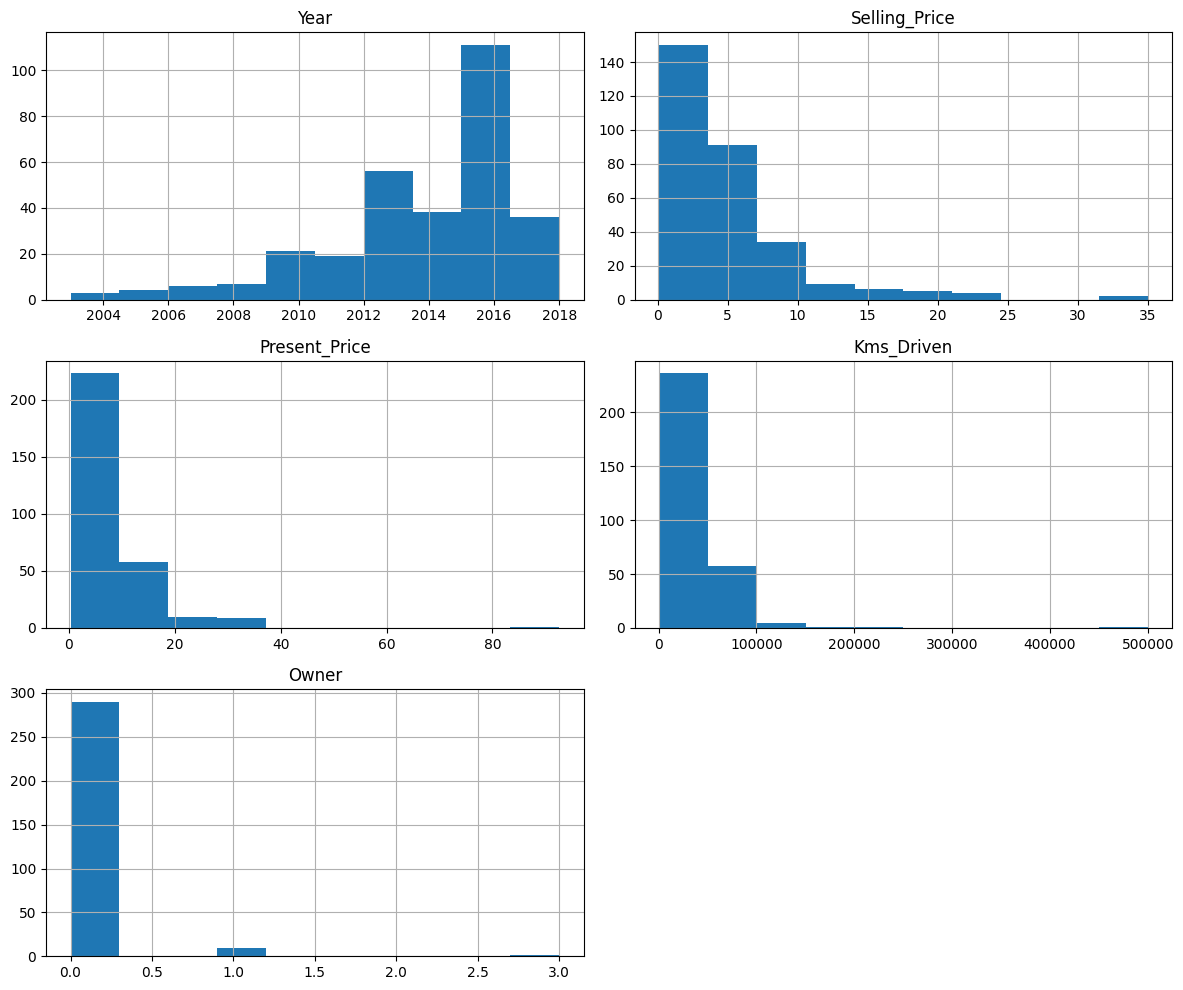

In [276]:
cars_full.hist(figsize=(12,10))
plt.tight_layout()

Our goals is to predict the selling price of a used car

Present price - is what a new car would cost atm

Prices are scaled obviously

Attributes have very different scales

## Ok let's create a test set (but first stratifying samples)

We can use the row index as a unique identifier! 

We have a lot of categorical attributes, some categories have very few values... -- this we think about AFTER creating test set. The test set SHOULD mirror real world data. 

Do we need to do stratified sampling for any important attribute, like the book did with median income?

We have a very small data set... if we do random sampling, we might introduce sampling bias... Wich ones should we stratify..? 

Let's stratify on 
- Car age : it is maybe the most important and has uneven distribution 

Let's handle the rare categories later in:
- Fuel type 
- Transmission 


In [277]:
cars_full["Year"].value_counts().sort_index()

Year
2003     2
2004     1
2005     4
2006     4
2007     2
2008     7
2009     6
2010    15
2011    19
2012    23
2013    33
2014    38
2015    61
2016    50
2017    35
2018     1
Name: count, dtype: int64

We transform Years into Age, because that is more important information here. W

In [278]:
cars_full["Age"]  = 2020 - cars_full["Year"] # new improved feature

cars_full["Age_bin"] = pd.cut(cars_full["Age"], bins=[0,3,6,10,20], labels=False) #temporary column will be used in stratification

splitter = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42) #object of the class

for train_index, test_index in splitter.split(cars_full, cars_full["Age_bin"]): 
    strat_train_set = cars_full.loc[train_index]
    strat_test_set = cars_full.loc[test_index]   #stratified splitting into train_set and test_set 

for set_ in (strat_train_set, strat_test_set):
    set_.drop("Age_bin", axis=1, inplace=True) #removes the help column in both sets 

## Now to EDA

We create a copy of strat_train_set to experiment on, a copy of the full training set

In [279]:
cars = strat_train_set.copy()

In [280]:
corr_matrix = cars.corr(numeric_only=True)
corr_matrix["Selling_Price"]

Year             0.223733
Selling_Price    1.000000
Present_Price    0.878594
Kms_Driven       0.060692
Owner           -0.087127
Age             -0.223733
Name: Selling_Price, dtype: float64

array([[<Axes: xlabel='Selling_Price', ylabel='Selling_Price'>,
        <Axes: xlabel='Age', ylabel='Selling_Price'>,
        <Axes: xlabel='Present_Price', ylabel='Selling_Price'>],
       [<Axes: xlabel='Selling_Price', ylabel='Age'>,
        <Axes: xlabel='Age', ylabel='Age'>,
        <Axes: xlabel='Present_Price', ylabel='Age'>],
       [<Axes: xlabel='Selling_Price', ylabel='Present_Price'>,
        <Axes: xlabel='Age', ylabel='Present_Price'>,
        <Axes: xlabel='Present_Price', ylabel='Present_Price'>]],
      dtype=object)

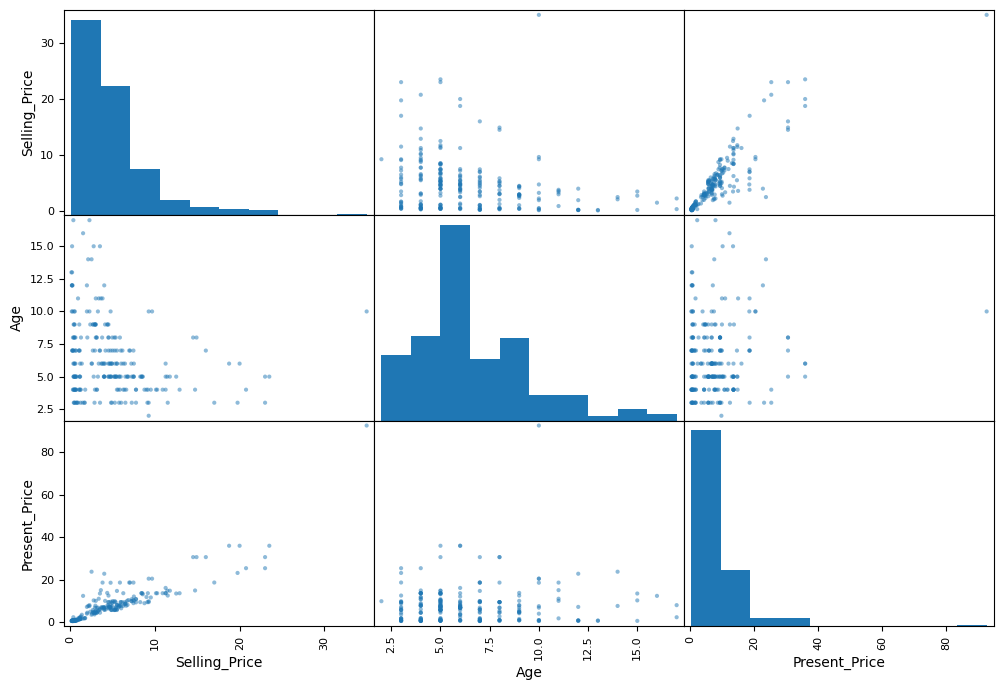

In [281]:
attributes = ["Selling_Price", "Age", "Present_Price"]

scatter_matrix(cars[attributes], figsize=(12,8))

In [282]:
cars.info()

<class 'pandas.DataFrame'>
Index: 240 entries, 229 to 3
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       240 non-null    str    
 1   Year           240 non-null    int64  
 2   Selling_Price  240 non-null    float64
 3   Present_Price  240 non-null    float64
 4   Kms_Driven     240 non-null    int64  
 5   Fuel_Type      240 non-null    str    
 6   Seller_Type    240 non-null    str    
 7   Transmission   240 non-null    str    
 8   Owner          240 non-null    int64  
 9   Age            240 non-null    int64  
dtypes: float64(2), int64(4), str(4)
memory usage: 20.6 KB


## Let's clean the data

Before preparing the data - we revert to a new clean copy of the training set 

We also seperate the predictors and the labels, since we don't necessarily want to apply the same transformations to them

In [283]:
cars = strat_train_set.drop("Selling_Price", axis=1) # drop creates a copy

cars_labels = strat_train_set["Selling_Price"].copy()

We can't have features that are too correlated with eachother, so we remove Year

Also Car Name doesn't really add any valuable information

In [284]:
cars.drop(["Year", "Car_Name"], axis=1, inplace=True)

We don't have any missing values

We do have 3 categorical attributes we need to deal with, as a regression cannot deal with text. We need to encode them somehow. 

We also need to to scaling, otherwise models will be biased toward the features with the biggest numbers.
But before scaling, we should "log transform" the right-squewed attributes: Age, Present Price, Kms_Driven, Selling Price-

Age has severla modes..

Owner with variables 0, 1, 3 is actually categories in disguise... Numbers don't automatically mean numeric. Clues:
- The values are few and discrete
- The values correspond to real-world categories (first owner, second owner, third owner), so they are actually labels 

In [285]:
categorical_cols = ["Transmission", "Seller_Type", "Fuel_Type"] 
cat_pipeline = OneHotEncoder(sparse_output=False, handle_unknown="ignore") # returns regular dense numpy array. Ignores unseen categories

numeric_cols = cars.select_dtypes(include=['number']).columns.tolist() #ColumnTransformer expects column NAMES, not a df
numeric_cols.remove("Owner") # this actually pre-encoded, so NOT numeric

right_squewed_cols = ["Age", "Present_Price", "Kms_Driven"]

log_pipeline = make_pipeline( 
    FunctionTransformer(np.log1p, inverse_func=np.expm1, feature_names_out="one-to-one")
)

preprocessor = ColumnTransformer(  #transformer capable of handling all columns
    transformers=[
        ("categorical", cat_pipeline, categorical_cols),
        ("log", log_pipeline, right_squewed_cols), 
        ("numerical_scaled", StandardScaler(), numeric_cols)
    ],
    remainder="drop"
)



When the ColumnTransformer is ready, it is time to apply it to the data

In [286]:
cars_prepared = preprocessor.fit_transform(cars)  #returns numpy array! 
cars_prepared.shape

(240, 13)

In [287]:
preprocessor.get_feature_names_out

<bound method ColumnTransformer.get_feature_names_out of ColumnTransformer(transformers=[('categorical',
                                 OneHotEncoder(handle_unknown='ignore',
                                               sparse_output=False),
                                 ['Transmission', 'Seller_Type', 'Fuel_Type']),
                                ('log',
                                 Pipeline(steps=[('functiontransformer',
                                                  FunctionTransformer(feature_names_out='one-to-one',
                                                                      func=<ufunc 'log1p'>,
                                                                      inverse_func=<ufunc 'expm1'>))]),
                                 ['Age', 'Present_Price', 'Kms_Driven']),
                                ('numerical_scaled', StandardScaler(),
                                 ['Present_Price', 'Kms_Driven', 'Age'])])>

## Select and Train a Model

In [288]:
lin_reg = make_pipeline(preprocessor, LinearRegression())

lin_reg.fit(cars, cars_labels) 

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('columntransformer', ...), ('linearregression', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('categorical', ...), ('log', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of 

The target must be transformed seperately (if it needs it) . När du sedan skriver koden för att träna din första modell, då är det dags att plocka fram TransformedTargetRegressor. se s.81
Vår target är right-squewed so we want to log-transform it

In [289]:
from sklearn.compose import TransformedTargetRegressor

log_transformer = FunctionTransformer(np.log1p, inverse_func=np.expm1)

reg = TransformedTargetRegressor(
    regressor = LinearRegression(),
    transformer= log_transformer)

model = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", reg)
])


At the moment, the features used are many - 7 predictors of the target Selling_Price. 

In [291]:
model.fit(cars, cars_labels)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('categorical', ...), ('log', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the differen

Evaluating on the training data

In [292]:
car_predictions = model.predict(cars)
car_predictions[:5]

array([ 4.28845486,  5.30022928, 10.31405186,  4.96132479,  4.22079165])

In [293]:
lin_rmse = root_mean_squared_error(cars_labels, car_predictions)
lin_rmse

1.0695307622832153

In [294]:
cars_labels.describe()

count    240.000000
mean       4.768292
std        4.905380
min        0.120000
25%        1.050000
50%        3.925000
75%        6.250000
max       35.000000
Name: Selling_Price, dtype: float64

Hmm... typical prediction error is around 1.26 (from training set). Most cars selling price range between 0-10. Not too bad.

När du beräknar RMSE på en enda datamängd (t.ex. hela träningssetet) får du en punktuppskattning
. Du får ett enda tal (t.ex. 68 973 dollar), men du vet inte hur mycket detta tal skulle variera om du använde annan data

Korsvalidering ger dig en hel array av värden (ofta RMSE-värden från varje fold)
. Detta gör att du kan beräkna både ett medelvärde (den förväntade prestandan) och en standardavvikelse
. Standardavvikelsen talar om för dig hur precis din uppskattning är och hur känslig modellen är för de specifika träningsdata den får
.

## Cross-Validation

In [295]:
from sklearn.model_selection import cross_val_score

# we will get 10 RMSE
lin_rmses = -cross_val_score(model, cars, cars_labels, scoring="neg_root_mean_squared_error", cv=10)

pd.Series(lin_rmses).describe()

count    10.000000
mean      1.114145
std       0.323367
min       0.822256
25%       0.862183
50%       1.069532
75%       1.203096
max       1.883845
dtype: float64

It is good that the mean rmse from cross-validation is lower than the rmse from the training data - the other way around would have meant over-fitting

## Fine-tune the model

As opposed to Grid-Search, Randomized search doesnt try every combination. We need to define good ranges where the best values are likely to be found. 


Turns out a linear regression model doesn't need tuning

In [296]:
from scipy.stats import randint

param_distribs = {}

## Evaluate the system on the test set

If you dropped columns in your training data, then your test data must drop the exact same columns in the exact same way, or the pipeline will break.

In [298]:
X_test = strat_test_set.drop("Selling_Price", axis=1)
y_test = strat_test_set["Selling_Price"].copy()

X_test.drop(["Year", "Car_Name"], axis=1, inplace=True)

final_predictions = model.predict(X_test)

final_rmse = root_mean_squared_error(y_test, final_predictions)
final_rmse

1.2640834537953214

a little worse, but not too shabby

You might want to have an idea of how precise this estimate is. For this we can compute a 95% comfidence interval for the generalization error. 

Gives an idea of how much the results can vary dependening on what data point the model gets. 